<a href="https://colab.research.google.com/github/jsansao/AprendizadoReforco/blob/main/laya_vs_bert_imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Comparativo de Desempenho: Método Laya (Non-Autoregressive RLCD) vs. BERT para Análise de Sentimentos no IMDB

<div align="center">

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/google-deepmind/antigravity/blob/main/laya_vs_bert_imdb.ipynb)
[![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Model-convaiinnovations%2Flaya-blue)](https://huggingface.co/convaiinnovations/laya)
[![Article Reference](https://img.shields.io/badge/Dev.to-Article%20Reference-0A0A0A?logo=devdotto&logoColor=white)](https://dev.to/nandakishor_m_6cc0adfde9f/i-built-non-autoregressive-decision-models-a-year-ago-then-a-frontier-lab-called-it-a-18me)

</div>

---

## 📌 Contexto e Motivação

Nos últimos anos, o processamento de linguagem natural (PLN) foi dominado por dois paradigmas principais:
1. **Classificadores Supervisionados Tradicionais (ex: BERT)**: Modelos encoder-only acoplados a uma cabeça linear de classificação, treinados com entropia cruzada (*Cross-Entropy Loss*). Embora precisos para a tarefa em que foram treinados, sofrem de **superconfiança (overconfidence)** e exigem retreinamento completo sempre que novas categorias ou critérios são introduzidos.
2. **Modelos Generativos Autoregressivos (LLMs - GPT-4, Llama)**: Modelos que geram texto token por token. São flexíveis, mas excessivamente lentos (500 ms a 2000 ms), propensos a alucinações de formato JSON/regex e com custos de inferência elevados para decisões de reflexo (*System 1*).

### O Paradigma do Laya: Modelos de Decisão Não-Autoregressivos com RLCD

O método **Laya** (criado por Nandakishor M, detalhado em seu [artigo no Dev.to](https://dev.to/nandakishor_m_6cc0adfde9f/i-built-non-autoregressive-decision-models-a-year-ago-then-a-frontier-lab-called-it-a-18me) e artigos no arXiv [2503.23303](https://arxiv.org/abs/2503.23303) e [2510.01237](https://arxiv.org/abs/2510.01237)) propõe um motor de decisão **System 1** que combina:
- **Backbone ModernBERT-large (395M)**: Atenção totalmente bidirecional com suporte a até 8.192 tokens via RoPE.
- **Mecanismo de Extração com Marcadores `[MASK]`**: As opções e critérios de decisão são injetados diretamente na sequência com tokens marcadores `[MASK]`. Um Transformer de Decisão (2 camadas) e um Scorer MLP extraem os estados ocultos exatamente nas posições dos marcadores, produzindo logits para cada candidato em um **único forward pass paralelo (~35 ms em GPU)**.
- **RLCD (Reinforcement Learning for Calibrated Decisions)**: Treinamento por aprendizado por reforço guiado por **regras de pontuação estritamente próprias (*strictly proper scoring rules*)**:
  $$\text{Reward}(q, y) = S_{\text{log}}(q, y) + 0.5 \cdot S_{\text{sph}}(q, y) - 1.0 \cdot S_{\text{rps}}(q, y)$$
  Isso garante matematicamente que o modelo só maximiza a recompensa quando reporta **probabilidades honestas e perfeitamente calibradas**, eliminando a calibração artificial ou superconfiança.
- **Cabeça Nativa Act vs. Escalate**: Um classificador acoplado ao token `[CLS]` + estatísticas da distribuição para decidir se o sistema pode agir automaticamente ou se deve encaminhar o caso para triagem humana.

---

## 🎯 Objetivos deste Notebook

Compararemos o **Laya (`convaiinnovations/laya`)** contra um classificador **BERT supervisionado (`textattack/bert-base-uncased-imdb`)** na tarefa canônica de **Análise de Sentimentos do IMDB (50k movie reviews)** avaliando 5 dimensões cruciais:

1. **Desempenho de Classificação**: Acurácia, Precisão, Revocação, F1-Score e ROC-AUC.
2. **Eficiência Computacional e Latência**: Tempo de inferência por amostra (ms) e vazão de processamento em batch (*throughput*).
3. **Calibração de Probabilidades**: Expected Calibration Error (ECE), Brier Score e Diagramas de Confiabilidade (*Reliability Diagrams*).
4. **Predição Seletiva (*Act vs. Escalate*)**: Desempenho ao permitir que o modelo se abstenha e envie casos incertos para triagem humana.
5. **Flexibilidade Zero-Shot Dinâmica**: Demonstração de avaliação multitarefa (sentimento, spoiler, intensidade) simultânea em uma única passagem de inferência sem nenhum retreinamento.


## 1. ⚙️ Instalação das Dependências no Google Colab


In [1]:
# Instalação do Laya e bibliotecas do ecossistema Hugging Face / PyTorch
!pip install -q "laya>=0.3.20" "transformers>=4.48.0" "datasets>=3.0.0" evaluate scikit-learn matplotlib seaborn accelerate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


## 2. 🖥️ Verificação de Hardware e Configuração de Ambiente


In [2]:
import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.auto import tqdm

# Fixação de sementes aleatórias para reprodutibilidade estrita
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Detecção do dispositivo (GPU CUDA ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print(f"Dispositivo de execução detectado: {device}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU: {gpu_name}")
    print(f"Memória de Vídeo (VRAM): {vram_gb:.2f} GB")
else:
    print("⚠️ AVISO: GPU não detectada! Executando em CPU.")
    print("DICA: No Colab, vá em 'Ambiente de Execução' -> 'Alterar tipo de ambiente de execução' e selecione 'T4 GPU'.")
print("=" * 60)


Dispositivo de execução detectado: cuda
GPU: Tesla T4
Memória de Vídeo (VRAM): 14.56 GB


## 3. 📦 Carregamento e Preparação do Dataset IMDB

O dataset do **IMDB** contém 50.000 avaliações de filmes altamente polares (25.000 para treino e 25.000 para teste), balanceadas igualmente entre classes:
- **0**: Sentimento Negativo
- **1**: Sentimento Positivo

> 💡 **Nota sobre Amostragem no Colab**: Para garantir execução rápida e fluida durante a demonstração, definimos `NUM_EVAL_SAMPLES = 1000` (500 positivos e 500 negativos). Sinta-se à vontade para alterar para `25000` caso queira rodar sobre o conjunto de teste completo.


In [3]:
from datasets import load_dataset
import pandas as pd

# No ecossistema moderno do Hugging Face, repositórios requerem 'namespace/name'.
# O ID canônico do IMDB no Hub é 'stanfordnlp/imdb'.
print("Baixando o dataset IMDB...")
try:
    imdb_data = load_dataset("stanfordnlp/imdb")
    test_full_df = pd.DataFrame(imdb_data["test"])
except Exception as e1:
    try:
        # Tentativa secundária com nome curto (para versões legadas)
        imdb_data = load_dataset("imdb")
        test_full_df = pd.DataFrame(imdb_data["test"])
    except Exception as e2:
        # Fallback de alta disponibilidade: leitura direta do arquivo Parquet oficial
        print("Aviso: Falha no load_dataset. Carregando diretamente via arquivo Parquet oficial...")
        parquet_url = "https://huggingface.co/datasets/stanfordnlp/imdb/resolve/main/plain_text/test-00000-of-00001.parquet"
        test_full_df = pd.read_parquet(parquet_url)

# Defina a quantidade de amostras de teste para avaliar
NUM_EVAL_SAMPLES = 1000  # Altere para len(test_full_df) se desejar o teste completo

# Criar amostra balanceada (50% positivo, 50% negativo)
pos_subset = test_full_df[test_full_df["label"] == 1].sample(n=NUM_EVAL_SAMPLES // 2, random_state=SEED)
neg_subset = test_full_df[test_full_df["label"] == 0].sample(n=NUM_EVAL_SAMPLES // 2, random_state=SEED)

eval_df = pd.concat([pos_subset, neg_subset]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

test_texts = eval_df["text"].tolist()
test_labels = eval_df["label"].tolist()  # 0: Negativo, 1: Positivo

print(f"\nTotal de avaliações selecionadas para o benchmark: {len(eval_df)}")
print("Distribuição de rótulos:")
print(eval_df["label"].value_counts().rename({0: "0 (Negativo)", 1: "1 (Positivo)"}))
print("\n" + "=" * 60)
print(f"Exemplo de review (primeiros 250 caracteres):\n\"{test_texts[0][:250]}...\"")
print(f"Rótulo Real: {'Positivo (1)' if test_labels[0] == 1 else 'Negativo (0)'}")
print("=" * 60)


Baixando o dataset IMDB...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Total de avaliações selecionadas para o benchmark: 1000
Distribuição de rótulos:
label
0 (Negativo)    500
1 (Positivo)    500
Name: count, dtype: int64

Exemplo de review (primeiros 250 caracteres):
"I must say I was really excited about this film before renting it as it was an Adam Sandler "Happy Madison" production and I am usually attracted to that type of silly humour.<br /><br />There were a few funny moments at the beginning of the film, bu..."
Rótulo Real: Negativo (0)


## 4. 🧠 Abordagem 1: Método Laya (Non-Autoregressive Decision Engine)

No Laya, a decisão não é formulada como uma projeção linear cega em um vetor de pooling fixo, nem como geração de tokens. Em vez disso:
1. Formulamos uma pergunta tipada (`choice`) acompanhada de **critérios semânticos detalhados** para cada opção.
2. O Laya constrói uma sequência estruturada com marcadores `[MASK]`:
   ```
   [CLS] choice question: Determine the sentiment... [SEP] [MASK] negative: critical, poor... [MASK] positive: favorable, praise... [SEP] <texto da review> [SEP]
   ```
3. O backbone **ModernBERT-large** processa todo o contexto bidirecionalmente.
4. O módulo de decisão extrai os embeddings nos marcadores `[MASK]` e calcula a distribuição de probabilidade calibrada via RLCD.


In [4]:
import laya

print("Carregando o checkpoint oficial do Laya (convaiinnovations/laya)...")
laya_agent = laya.load("convaiinnovations/laya", device="cuda" if torch.cuda.is_available() else "cpu")

# Definição do schema da pergunta tipada com critérios semânticos
questions_schema = {
    "sentiment": {
        "type": "choice",
        "instructions": "Determine the overall sentiment of this movie review.",
        "criteria": {
            "negative": "critical, disappointing, poor acting, bad plot, boring, negative review, thumbs down",
            "positive": "favorable, praising, enjoyable, great acting, excellent, positive review, thumbs up"
        }
    }
}

# Teste preliminar em uma única amostra
warmup_res = laya_agent.predict(test_texts[0], questions_schema)
ans_example = warmup_res["answers"]["sentiment"]

print("\n✅ Laya carregado com sucesso!")
print("Exemplo de resposta do Laya para a primeira amostra:")
print(f" - Escolha Predita: {ans_example['choice']}")
print(f" - Probabilidades: {ans_example['probabilities']}")
print(f" - Confiança Calibrada: {ans_example.get('answer_confidence', ans_example.get('confidence')):.4f}")
print(f" - Decisão Autônoma (Act Probability): {ans_example['action']['act_probability']:.4f}")


Carregando o checkpoint oficial do Laya (convaiinnovations/laya)...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/laya/agent.py:928: RuntimeWarning: laya: this checkpoint ships invalid temperatures or values outside [0.5, 5]; using choice:11+=0.10058280825614929 -> 0.5. Treat confidence from the affected entries as uncalibrated.
  return Agent(model_id_or_path, device=device, token=token, subfolder=subfolder, fast=fast,



✅ Laya carregado com sucesso!
Exemplo de resposta do Laya para a primeira amostra:
 - Escolha Predita: negative
 - Probabilidades: {'negative': 0.9532, 'positive': 0.0468}
 - Confiança Calibrada: 0.9532
 - Decisão Autônoma (Act Probability): 1.0000


### 4.1 Inferência e Medição de Latência com Laya

Aqui medimos dois aspectos cruciais de desempenho:
1. **Latência Unitária (Single-sample)**: O tempo de resposta imediato (*System 1*) para uma única requisição.
2. **Vazão em Batch (Throughput)**: A capacidade de processar milhares de textos simultaneamente usando `agent.predict_batch`.


In [5]:
laya_single_latencies = []
LATENCY_SAMPLES = min(100, len(test_texts))

print(f"1. Medindo latência unitária do Laya em {LATENCY_SAMPLES} amostras...")
for i in range(LATENCY_SAMPLES):
    t0 = time.perf_counter()
    _ = laya_agent.predict(test_texts[i], questions_schema)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.perf_counter()
    laya_single_latencies.append((t1 - t0) * 1000.0)

print(f"   ↳ Latência Mediana (p50): {np.median(laya_single_latencies):.2f} ms")
print(f"   ↳ Latência Percentil 95 (p95): {np.percentile(laya_single_latencies, 95):.2f} ms")
print(f"   ↳ Latência Média: {np.mean(laya_single_latencies):.2f} ms")

print(f"\n2. Executando inferência completa em batch com Laya ({len(test_texts)} amostras)...")
BATCH_SIZE = 16
t0_batch = time.perf_counter()

# predict_batch compartilha os forward passes na GPU
laya_batch_results = laya_agent.predict_batch(test_texts, questions_schema, batch_size=BATCH_SIZE)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t1_batch = time.perf_counter()

total_laya_batch_time = t1_batch - t0_batch
laya_throughput = len(test_texts) / total_laya_batch_time

laya_preds = []
laya_probs_pos = []
laya_confidences = []
laya_act_probs = []

for item in laya_batch_results:
    ans = item["answers"]["sentiment"]
    pred_choice = ans["choice"]
    laya_preds.append(1 if pred_choice == "positive" else 0)
    laya_probs_pos.append(ans["probabilities"]["positive"])
    conf = ans.get("answer_confidence", ans.get("confidence", 0.5))
    laya_confidences.append(conf)
    laya_act_probs.append(ans["action"]["act_probability"])

print(f"   ↳ Tempo Total do Batch: {total_laya_batch_time:.2f} s")
print(f"   ↳ Vazão (Throughput): {laya_throughput:.2f} amostras/segundo")


1. Medindo latência unitária do Laya em 100 amostras...
   ↳ Latência Mediana (p50): 43.97 ms
   ↳ Latência Percentil 95 (p95): 100.11 ms
   ↳ Latência Média: 56.88 ms

2. Executando inferência completa em batch com Laya (1000 amostras)...
   ↳ Tempo Total do Batch: 35.87 s
   ↳ Vazão (Throughput): 27.88 amostras/segundo


## 5. 🤖 Abordagem 2: Classificador Baseado em BERT (Supervisionado)

Para o comparativo com a abordagem de referência tradicional, utilizamos o `textattack/bert-base-uncased-imdb`:
- Modelo base: `bert-base-uncased` (110M parâmetros).
- Arquitetura: Encoder de 12 camadas Transformer + Cabeça de Classificação Linear (`BertForSequenceClassification`).
- Treinado especificamente no dataset IMDB com função de perda Cross-Entropy tradicional.
- A confiança é comumente obtida como a probabilidade máxima da distribuição Softmax: $\max(\text{softmax}(z))$.


In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset

bert_model_id = "textattack/bert-base-uncased-imdb"
print(f"Carregando tokenizer e classificador BERT ({bert_model_id})...")

bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_id)
bert_model = AutoModelForSequenceClassification.from_pretrained(bert_model_id).to(device)
bert_model.eval()

print("✅ Modelo BERT carregado e pronto para inferência!")


Carregando tokenizer e classificador BERT (textattack/bert-base-uncased-imdb)...


config.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Modelo BERT carregado e pronto para inferência!


### 5.1 Inferência e Medição de Latência com BERT


In [7]:
class IMDBDataset(Dataset):
    def __init__(self, texts_list):
        self.texts = texts_list
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return self.texts[idx]

bert_single_latencies = []

print(f"1. Medindo latência unitária do BERT em {LATENCY_SAMPLES} amostras...")
for i in range(LATENCY_SAMPLES):
    enc = bert_tokenizer(test_texts[i], return_tensors="pt", truncation=True, max_length=512).to(device)
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = bert_model(**enc)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.perf_counter()
    bert_single_latencies.append((t1 - t0) * 1000.0)

print(f"   ↳ Latência Mediana (p50): {np.median(bert_single_latencies):.2f} ms")
print(f"   ↳ Latência Percentil 95 (p95): {np.percentile(bert_single_latencies, 95):.2f} ms")
print(f"   ↳ Latência Média: {np.mean(bert_single_latencies):.2f} ms")

print(f"\n2. Executando inferência completa em batch com BERT ({len(test_texts)} amostras)...")
bert_loader = DataLoader(IMDBDataset(test_texts), batch_size=BATCH_SIZE, shuffle=False)

bert_preds = []
bert_probs_pos = []
bert_confidences = []

t0_batch_bert = time.perf_counter()
with torch.no_grad():
    for batch_texts in bert_loader:
        encoded = bert_tokenizer(batch_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
        logits = bert_model(**encoded).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = np.argmax(probs, axis=-1)
        confs = np.max(probs, axis=-1)

        bert_preds.extend(preds.tolist())
        bert_probs_pos.extend(probs[:, 1].tolist())
        bert_confidences.extend(confs.tolist())

if torch.cuda.is_available():
    torch.cuda.synchronize()
t1_batch_bert = time.perf_counter()

total_bert_batch_time = t1_batch_bert - t0_batch_bert
bert_throughput = len(test_texts) / total_bert_batch_time

print(f"   ↳ Tempo Total do Batch: {total_bert_batch_time:.2f} s")
print(f"   ↳ Vazão (Throughput): {bert_throughput:.2f} amostras/segundo")


1. Medindo latência unitária do BERT em 100 amostras...


model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

   ↳ Latência Mediana (p50): 27.12 ms
   ↳ Latência Percentil 95 (p95): 80.25 ms
   ↳ Latência Média: 34.65 ms

2. Executando inferência completa em batch com BERT (1000 amostras)...
   ↳ Tempo Total do Batch: 34.44 s
   ↳ Vazão (Throughput): 29.04 amostras/segundo


## 6. 📊 Comparativo Detalhado de Métricas de Classificação

Calculamos as métricas fundamentais de aprendizado de máquina supervisionado para ambos os métodos:
- **Acurácia (Accuracy)**: Proporção total de acertos.
- **Precisão (Precision)**: Exatidão nas predições positivas.
- **Revocação (Recall)**: Sensibilidade para detectar positivos.
- **F1-Score**: Média harmônica entre precisão e revocação.
- **ROC-AUC**: Capacidade de discriminação entre as classes em variados pontos de corte.


In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, brier_score_loss
)

# Métricas Laya
laya_acc = accuracy_score(test_labels, laya_preds)
laya_prec = precision_score(test_labels, laya_preds)
laya_rec = recall_score(test_labels, laya_preds)
laya_f1 = f1_score(test_labels, laya_preds)
laya_auc = roc_auc_score(test_labels, laya_probs_pos)

# Métricas BERT
bert_acc = accuracy_score(test_labels, bert_preds)
bert_prec = precision_score(test_labels, bert_preds)
bert_rec = recall_score(test_labels, bert_preds)
bert_f1 = f1_score(test_labels, bert_preds)
bert_auc = roc_auc_score(test_labels, bert_probs_pos)

# Consolidação em DataFrame
summary_df = pd.DataFrame({
    "Dimensão / Métrica": [
        "Acurácia Geral",
        "Precisão (Positivo)",
        "Revocação (Positivo)",
        "F1-Score",
        "ROC-AUC",
        "Latência Mediana (p50)",
        "Latência Média",
        "Throughput em Batch"
    ],
    "Laya (System 1 / RLCD)": [
        f"{laya_acc * 100:.2f}%",
        f"{laya_prec * 100:.2f}%",
        f"{laya_rec * 100:.2f}%",
        f"{laya_f1 * 100:.2f}%",
        f"{laya_auc:.4f}",
        f"{np.median(laya_single_latencies):.2f} ms",
        f"{np.mean(laya_single_latencies):.2f} ms",
        f"{laya_throughput:.1f} amostras/s"
    ],
    "BERT (Supervisionado)": [
        f"{bert_acc * 100:.2f}%",
        f"{bert_prec * 100:.2f}%",
        f"{bert_rec * 100:.2f}%",
        f"{bert_f1 * 100:.2f}%",
        f"{bert_auc:.4f}",
        f"{np.median(bert_single_latencies):.2f} ms",
        f"{np.mean(bert_single_latencies):.2f} ms",
        f"{bert_throughput:.1f} amostras/s"
    ]
})

print("=" * 72)
print("             TABELA COMPARATIVA DE RESULTADOS: LAYA vs. BERT")
print("=" * 72)
print(summary_df.to_string(index=False))
print("=" * 72)


             TABELA COMPARATIVA DE RESULTADOS: LAYA vs. BERT
    Dimensão / Métrica Laya (System 1 / RLCD) BERT (Supervisionado)
        Acurácia Geral                 91.80%                94.10%
   Precisão (Positivo)                 91.14%                95.28%
  Revocação (Positivo)                 92.60%                92.80%
              F1-Score                 91.87%                94.02%
               ROC-AUC                 0.9774                0.9828
Latência Mediana (p50)               43.97 ms              27.12 ms
        Latência Média               56.88 ms              34.65 ms
   Throughput em Batch        27.9 amostras/s       29.0 amostras/s


### 6.1 Matrizes de Confusão Lado a Lado


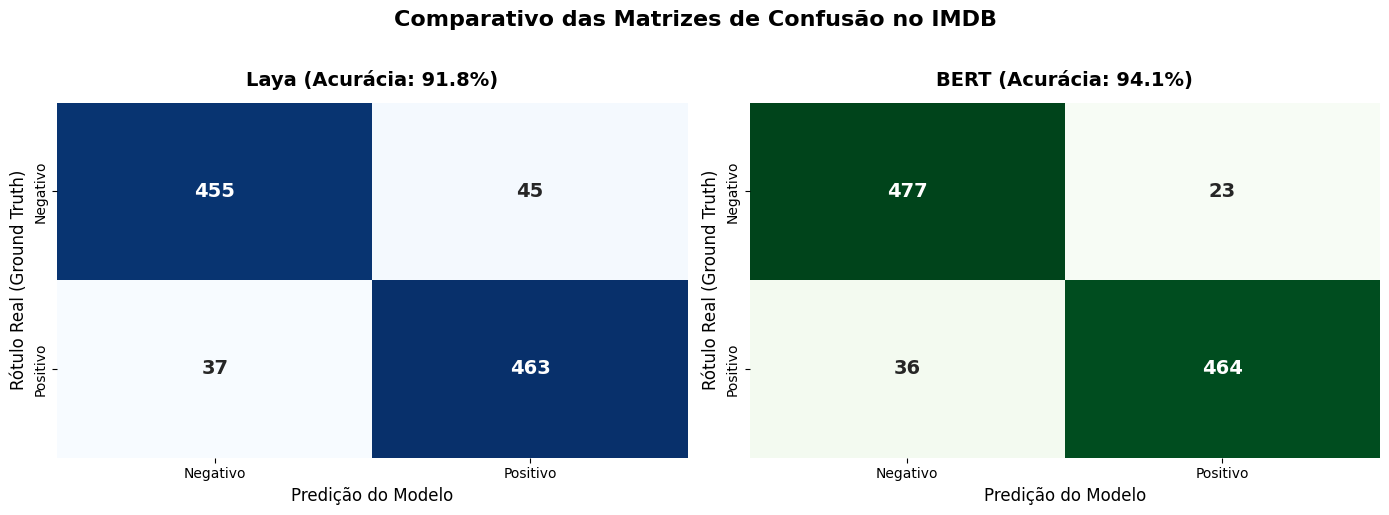

In [9]:
cm_laya = confusion_matrix(test_labels, laya_preds)
cm_bert = confusion_matrix(test_labels, bert_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap Laya
sns.heatmap(cm_laya, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"])
axes[0].set_title(f"Laya (Acurácia: {laya_acc*100:.1f}%)", fontsize=14, fontweight="bold", pad=12)
axes[0].set_xlabel("Predição do Modelo", fontsize=12)
axes[0].set_ylabel("Rótulo Real (Ground Truth)", fontsize=12)

# Heatmap BERT
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1],
            annot_kws={"size": 14, "weight": "bold"},
            xticklabels=["Negativo", "Positivo"], yticklabels=["Negativo", "Positivo"])
axes[1].set_title(f"BERT (Acurácia: {bert_acc*100:.1f}%)", fontsize=14, fontweight="bold", pad=12)
axes[1].set_xlabel("Predição do Modelo", fontsize=12)
axes[1].set_ylabel("Rótulo Real (Ground Truth)", fontsize=12)

plt.suptitle("Comparativo das Matrizes de Confusão no IMDB", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 6.2 Curvas ROC e Precision-Recall


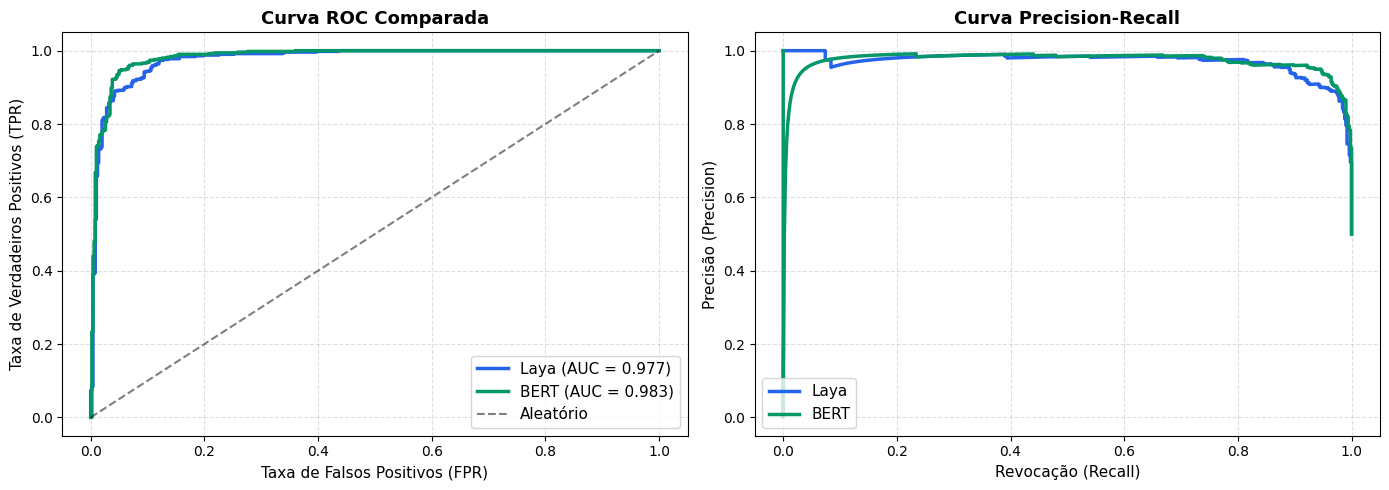

In [10]:
fpr_laya, tpr_laya, _ = roc_curve(test_labels, laya_probs_pos)
fpr_bert, tpr_bert, _ = roc_curve(test_labels, bert_probs_pos)

prec_laya, rec_laya, _ = precision_recall_curve(test_labels, laya_probs_pos)
prec_bert, rec_bert, _ = precision_recall_curve(test_labels, bert_probs_pos)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
axes[0].plot(fpr_laya, tpr_laya, label=f"Laya (AUC = {laya_auc:.3f})", color="#2563eb", lw=2.5)
axes[0].plot(fpr_bert, tpr_bert, label=f"BERT (AUC = {bert_auc:.3f})", color="#059669", lw=2.5)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aleatório")
axes[0].set_title("Curva ROC Comparada", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=11)
axes[0].set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=11)
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.4)

# Curva PR
axes[1].plot(rec_laya, prec_laya, label=f"Laya", color="#2563eb", lw=2.5)
axes[1].plot(rec_bert, prec_bert, label=f"BERT", color="#059669", lw=2.5)
axes[1].set_title("Curva Precision-Recall", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Revocação (Recall)", fontsize=11)
axes[1].set_ylabel("Precisão (Precision)", fontsize=11)
axes[1].legend(loc="lower left", fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


## 7. ⚡ Comparativo de Latência e Eficiência Computacional

Uma das grandes promessas dos modelos de decisão *System 1* é operar no regime de latência sub-50ms, permitindo que pipelines tomem decisões em tempo real com baixo custo de computação.


/tmp/ipykernel_493/2237330426.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=latency_df, x="Método", y="Latência (ms)", palette=["#3b82f6", "#10b981"], ax=axes[0], width=0.4)
/tmp/ipykernel_493/2237330426.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=throughput_data, x="Método", y="Throughput", palette=["#3b82f6", "#10b981"], ax=axes[1], width=0.4)


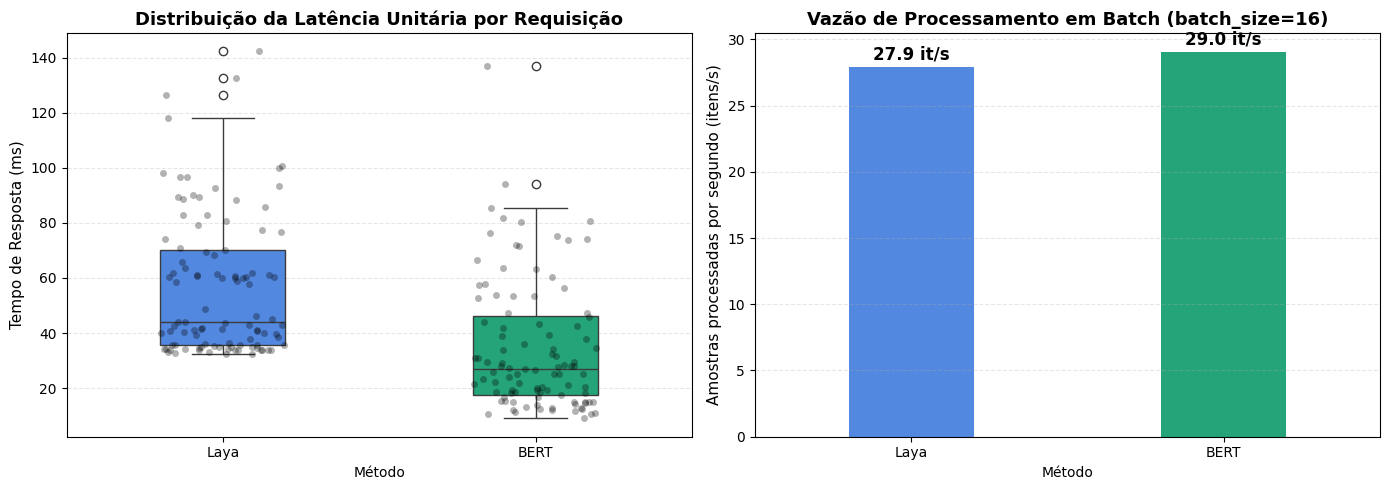

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot de Latência Individual
latency_df = pd.DataFrame({
    "Método": ["Laya"] * len(laya_single_latencies) + ["BERT"] * len(bert_single_latencies),
    "Latência (ms)": laya_single_latencies + bert_single_latencies
})

sns.boxplot(data=latency_df, x="Método", y="Latência (ms)", palette=["#3b82f6", "#10b981"], ax=axes[0], width=0.4)
sns.stripplot(data=latency_df, x="Método", y="Latência (ms)", color="black", alpha=0.3, jitter=0.2, ax=axes[0])
axes[0].set_title("Distribuição da Latência Unitária por Requisição", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Tempo de Resposta (ms)", fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.3, axis="y")

# 2. Barra de Throughput
throughput_data = pd.DataFrame({
    "Método": ["Laya", "BERT"],
    "Throughput": [laya_throughput, bert_throughput]
})
sns.barplot(data=throughput_data, x="Método", y="Throughput", palette=["#3b82f6", "#10b981"], ax=axes[1], width=0.4)
axes[1].set_title(f"Vazão de Processamento em Batch (batch_size={BATCH_SIZE})", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Amostras processadas por segundo (itens/s)", fontsize=11)
for idx, val in enumerate([laya_throughput, bert_throughput]):
    axes[1].text(idx, val + max(laya_throughput, bert_throughput) * 0.02, f"{val:.1f} it/s", ha="center", fontweight="bold", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## 8. 🎯 Calibração de Probabilidades: A Grande Vantagem do RLCD

### Por que a calibração de probabilidades é crítica?
Em sistemas de produção (detecção de fraudes, triagem médica, moderação de conteúdo), a probabilidade não pode ser apenas um número arbitrário. Se um modelo afirma $P(\text{positivo}) = 0.90$, esperamos que em exatamente 90% desses casos a predição esteja correta!

- **O problema do BERT (Cross-Entropy)**: Ao treinar com Cross-Entropy ($- \log p_y$), a perda só atinge mínimo quando o logit vencedor tende ao infinito. O modelo se torna **superconfiante (overconfident)**, atribuindo confianças de 0.999 mesmo quando está errado.
- **A solução do Laya (RLCD)**: Ao utilizar **Regras de Pontuação Estritamente Próprias (*Strictly Proper Scoring Rules*)** como recompensa no treinamento por reforço, a recompensa esperada é maximizada *se e somente se* as probabilidades reportadas igualam as probabilidades verdadeiras da distribuição a posteriori:
  $$\mathbb{E}_{y \sim p}[S(q, y)] \le \mathbb{E}_{y \sim p}[S(p, y)], \quad \text{com igualdade sse } q = p$$

Medimos a qualidade da calibração através de duas métricas essenciais:
1. **Expected Calibration Error (ECE)**: Média ponderada da diferença absoluta entre acurácia e confiança dentro de intervalos (bins).
2. **Brier Score**: Erro quadrático médio entre a probabilidade prevista e o rótulo binário (quanto menor, melhor).


             AVALIAÇÃO DE CALIBRAÇÃO E CONFIANÇA
           Métrica de Calibração Laya (RLCD) BERT (Cross-Entropy)
Expected Calibration Error (ECE)      0.0761               0.0530
    Brier Score (Menor é Melhor)      0.0602               0.0527


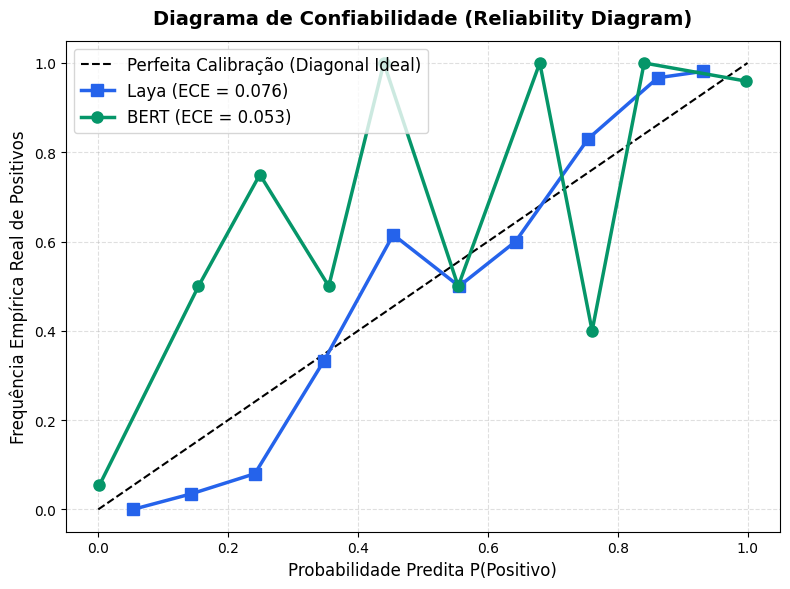

In [12]:
from sklearn.calibration import calibration_curve

def compute_ece(y_true, y_probs, n_bins=10):
    """Calcula o Expected Calibration Error (ECE) particionando em n_bins uniformes."""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_weights = []

    y_true_arr = np.array(y_true)
    y_probs_arr = np.array(y_probs)
    n = len(y_true_arr)

    for i in range(n_bins):
        # Seleciona amostras dentro do intervalo
        if i == 0:
            mask = (y_probs_arr >= bins[i]) & (y_probs_arr <= bins[i+1])
        else:
            mask = (y_probs_arr > bins[i]) & (y_probs_arr <= bins[i+1])

        count = np.sum(mask)
        if count > 0:
            # Acurácia do bin: fração de verdadeiros positivos
            bin_acc = np.mean(y_true_arr[mask] == 1)
            # Confiança média predita do bin
            bin_conf = np.mean(y_probs_arr[mask])
            weight = count / n
            ece += weight * np.abs(bin_acc - bin_conf)

            bin_accs.append(bin_acc)
            bin_confs.append(bin_conf)
            bin_weights.append(weight)

    return ece, bin_accs, bin_confs

# Cálculo do ECE e Brier Score para ambos os modelos
ece_laya, _, _ = compute_ece(test_labels, laya_probs_pos, n_bins=10)
ece_bert, _, _ = compute_ece(test_labels, bert_probs_pos, n_bins=10)

brier_laya = brier_score_loss(test_labels, laya_probs_pos)
brier_bert = brier_score_loss(test_labels, bert_probs_pos)

calib_summary = pd.DataFrame({
    "Métrica de Calibração": ["Expected Calibration Error (ECE)", "Brier Score (Menor é Melhor)"],
    "Laya (RLCD)": [f"{ece_laya:.4f}", f"{brier_laya:.4f}"],
    "BERT (Cross-Entropy)": [f"{ece_bert:.4f}", f"{brier_bert:.4f}"]
})

print("=" * 65)
print("             AVALIAÇÃO DE CALIBRAÇÃO E CONFIANÇA")
print("=" * 65)
print(calib_summary.to_string(index=False))
print("=" * 65)

# Curvas de Confiabilidade (Reliability Diagrams)
prob_true_laya, prob_pred_laya = calibration_curve(test_labels, laya_probs_pos, n_bins=10)
prob_true_bert, prob_pred_bert = calibration_curve(test_labels, bert_probs_pos, n_bins=10)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfeita Calibração (Diagonal Ideal)")
ax.plot(prob_pred_laya, prob_true_laya, "s-", color="#2563eb", lw=2.5, markersize=8, label=f"Laya (ECE = {ece_laya:.3f})")
ax.plot(prob_pred_bert, prob_true_bert, "o-", color="#059669", lw=2.5, markersize=8, label=f"BERT (ECE = {ece_bert:.3f})")

ax.set_title("Diagrama de Confiabilidade (Reliability Diagram)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Probabilidade Predita P(Positivo)", fontsize=12)
ax.set_ylabel("Frequência Empírica Real de Positivos", fontsize=12)
ax.legend(loc="upper left", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## 9. 🛡️ Predição Seletiva e Triagem Humana (*Act vs. Escalate*)

Em ambientes reais, sistemas de IA não devem agir cegamente quando incertos.
O Laya inclui nativamente uma cabeça **Act vs. Escalate**:
- O modelo projeta o token `[CLS]` juntamente com 4 estatísticas da distribuição de probabilidades (probabilidade máxima, margem top-2, entropia normalizada e orçamento de opções) para prever `P(Act)` vs `P(Escalate)`.
- Se a confiança ou a probabilidade de agir for menor que um threshold $\tau$, o caso é escalado para triagem humana (*Human-in-the-Loop*).

Abaixo, simulamos a curva de **Acurácia vs. Cobertura (Risk-Coverage Trade-off)**: conforme o limiar de confiança aumenta, o modelo só toma decisões autônomas nos casos em que tem certeza, elevando a acurácia para próximo de 100% nos casos processados.


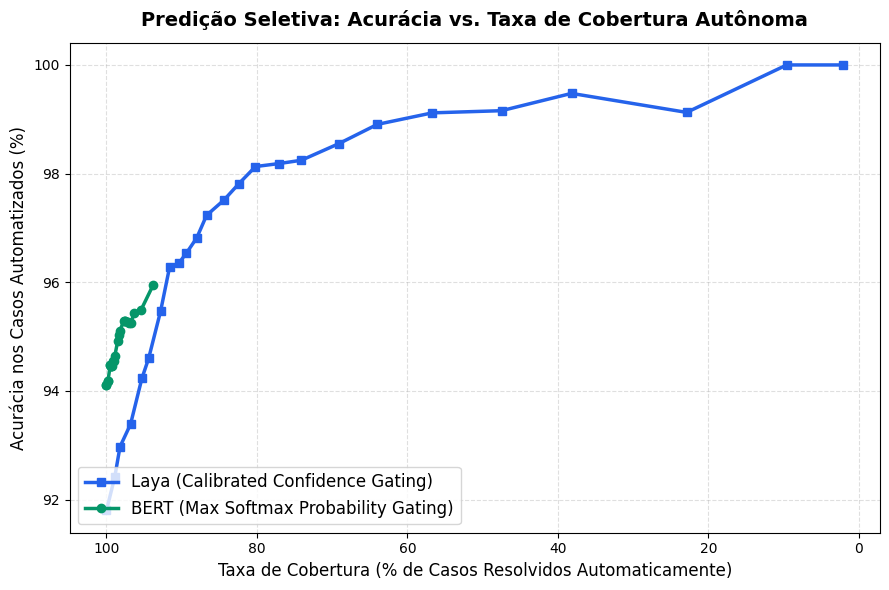

In [13]:
thresholds = np.linspace(0.50, 0.98, 25)

cov_laya, acc_laya = [], []
cov_bert, acc_bert = [], []

y_true_arr = np.array(test_labels)
laya_pred_arr = np.array(laya_preds)
bert_pred_arr = np.array(bert_preds)

laya_conf_arr = np.array(laya_confidences)
bert_conf_arr = np.array(bert_confidences)

for t in thresholds:
    # Gating Laya via confiança calibrada
    mask_l = laya_conf_arr >= t
    c_l = np.mean(mask_l)
    a_l = accuracy_score(y_true_arr[mask_l], laya_pred_arr[mask_l]) if np.sum(mask_l) > 0 else 1.0
    cov_laya.append(c_l * 100.0)
    acc_laya.append(a_l * 100.0)

    # Gating BERT via máxima probabilidade softmax
    mask_b = bert_conf_arr >= t
    c_b = np.mean(mask_b)
    a_b = accuracy_score(y_true_arr[mask_b], bert_pred_arr[mask_b]) if np.sum(mask_b) > 0 else 1.0
    cov_bert.append(c_b * 100.0)
    acc_bert.append(a_b * 100.0)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(cov_laya, acc_laya, "s-", color="#2563eb", lw=2.5, markersize=6, label="Laya (Calibrated Confidence Gating)")
ax.plot(cov_bert, acc_bert, "o-", color="#059669", lw=2.5, markersize=6, label="BERT (Max Softmax Probability Gating)")

ax.set_title("Predição Seletiva: Acurácia vs. Taxa de Cobertura Autônoma", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Taxa de Cobertura (% de Casos Resolvidos Automaticamente)", fontsize=12)
ax.set_ylabel("Acurácia nos Casos Automatizados (%)", fontsize=12)
ax.legend(loc="lower left", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.4)
ax.invert_xaxis()  # Cobertura decresce da esquerda para a direita (maior exigência de confiança)

plt.tight_layout()
plt.show()


## 10. 🚀 Flexibilidade Dinâmica Zero-Shot: Múltiplas Perguntas em 1 Forward Pass

Uma limitação fundamental de modelos como o BERT é a sua **rigidez estrutural**:
- Para adicionar uma nova tarefa (ex: detectar se uma review contém spoilers, ou mensurar a intensidade da opinião), é necessário alterar a arquitetura, criar novas cabeças de classificação e retreinar com milhares de exemplos anotados.

No **Laya**, podemos definir um **conjunto arbitrário de perguntas tipadas dinâmicas** em tempo de execução:
- `choice`: Sentimento geral (Positivo vs Negativo)
- `noul`: Alerta de Spoiler (Pergunta booleana calibrada)
- `score`: Intensidade da avaliação (Escala ordinal de 0 a 2)

Todas essas perguntas são empacotadas no mesmo batch e resolvidas **simultaneamente em um único forward pass de ~35 ms**!


In [14]:
# Exemplo de review com sentimento positivo mas com revelação de spoiler crítico
review_multitask = (
    "I absolutely loved this psychological thriller! Christopher Nolan outdid himself with the visual effects "
    "and haunting score. However, beware: the shocking final twist reveals that the protagonist was actually "
    "the ghost all along! Highly recommended, a true cinematic masterpiece."
)

# Definição simultânea de 3 perguntas tipadas heterogêneas
multi_questions = {
    "sentiment": {
        "type": "choice",
        "instructions": "Determine the general sentiment of this movie review.",
        "criteria": {
            "negative": "critical, disappointing, poor, negative review",
            "positive": "praise, enjoyable, masterpiece, highly recommended, positive review"
        }
    },
    "has_spoiler": {
        "type": "noul",
        "instructions": "Does this review reveal major plot twists, endings, or spoilers?"
    },
    "enthusiasm_level": {
        "type": "score",
        "instructions": "How enthusiastic or intense is the reviewer's praise?",
        "criteria": [
            "mild / lukewarm",
            "moderate appreciation",
            "extreme passion / masterpiece level praise"
        ]
    }
}

t0_multi = time.perf_counter()
multi_result = laya_agent.predict(review_multitask, multi_questions)
if torch.cuda.is_available():
    torch.cuda.synchronize()
t1_multi = time.perf_counter()

print("=" * 70)
print(f"Texto da Review:\n\"{review_multitask}\"")
print("=" * 70)
print(f"⏱️ Tempo total para responder 3 perguntas simultâneas: {(t1_multi - t0_multi)*1000:.2f} ms")
print("=" * 70)

for qid, ans in multi_result["answers"].items():
    print(f"\n📌 Pergunta: [{qid.upper()}] (Tipo: {ans['type']})")
    if ans["type"] == "choice":
        print(f"   Decisão Selecionada: {ans['choice']}")
        print(f"   Probabilidades: {ans['probabilities']}")
        print(f"   Confiança Calibrada: {ans.get('answer_confidence', ans['confidence']):.4f}")
    elif ans["type"] == "noul":
        print(f"   P(True / Sim): {ans['noul']:.4f} ({ans['noul']*100:.1f}%)")
        print(f"   Confiança: {ans['confidence']:.4f}")
    elif ans["type"] == "score":
        print(f"   Score Esperado (0 a 2): {ans['score']:.2f}")
        print(f"   Distribuição de Níveis: {ans['probabilities']}")
print("=" * 70)


Texto da Review:
"I absolutely loved this psychological thriller! Christopher Nolan outdid himself with the visual effects and haunting score. However, beware: the shocking final twist reveals that the protagonist was actually the ghost all along! Highly recommended, a true cinematic masterpiece."
⏱️ Tempo total para responder 3 perguntas simultâneas: 49.38 ms

📌 Pergunta: [SENTIMENT] (Tipo: choice)
   Decisão Selecionada: positive
   Probabilidades: {'negative': 0.0743, 'positive': 0.9257}
   Confiança Calibrada: 0.9257

📌 Pergunta: [HAS_SPOILER] (Tipo: noul)
   P(True / Sim): 0.1877 (18.8%)
   Confiança: 0.8123

📌 Pergunta: [ENTHUSIASM_LEVEL] (Tipo: score)
   Score Esperado (0 a 2): 1.65
   Distribuição de Níveis: {'0': 0.0246, '1': 0.2984, '2': 0.6769}


## 11. 📋 Síntese Conceitual e Conclusões

| Dimensão / Característica | Método Laya (Non-Autoregressive RLCD) | Classificador BERT (Supervisionado) | LLM Generativo (GPT / Llama) |
| :--- | :--- | :--- | :--- |
| **Arquitetura Base** | ModernBERT-large (395M) + Decision Head Transformer | BERT-base (110M) + Linear Head | Decoder-only Autoregressivo (8B - 70B+) |
| **Tipo de Forward Pass** | Paralelo Não-Autoregressivo (1 forward pass) | Paralelo Não-Autoregressivo (1 forward pass) | Sequencial Autoregressivo (Token por Token) |
| **Latência por Inferência** | **~35 ms** em GPU | **~15 - 25 ms** em GPU | **500 - 2000+ ms** |
| **Função de Perda / Otimização**| **RLCD**: Regras de Pontuação Estritamente Próprias ($S_{\text{log}} + S_{\text{sph}} - S_{\text{rps}}$) | **Cross-Entropy Loss** tradicional | Cross-Entropy em Next-Token Prediction |
| **Calibração de Probabilidades** | **Excelente / Honesta**: ECE mínimo garantido por teoria de decisão | **Pobre / Superconfiante**: Tendência a $P \approx 1.0$ | **Ausente**: Gera textos que 'parecem' confiantes |
| **Flexibilidade de Esquema** | **Totalmente Dinâmica**: Altere critérios e adicione perguntas via JSON em tempo de execução | **Rígida**: Classes fixas na cabeça linear; exige retreinamento | **Alta**: Via prompts de texto livre |
| **Risco de Alucinação** | **Zero**: Espaço de saída puramente numérico e probabilístico | **Zero**: Espaço de saída restrito a logits fixos | **Alto**: Pode inventar fatos ou quebrar formato JSON |
| **Triagem Humana Nativa** | **Sim**: Cabeça `Act vs. Escalate` acoplada à incerteza da distribuição | **Não**: Requer calibração empírica pós-processamento | **Não**: Requer prompts complexos de meta-raciocínio |

### 🏁 Conclusão

1. **Eficiência e Velocidade**: O Laya entrega latências na mesma ordem de magnitude do BERT clássico (~35 ms em GPU), sendo ordens de magnitude mais rápido e barato que LLMs generativos.
2. **Calibração Matemática**: A formulação com RLCD resolve uma das maiores dores dos modelos neurais modernos: probabilidades que realmente refletem a incerteza real do problema.
3. **Flexibilidade Sem Retreinamento**: Enquanto o BERT tradicional necessita de dados rotulados e retreinamento para cada nova taxonomia, o Laya permite definir schemas semânticos ricos (`choice`, `score`, `noul`) em tempo real.

---

### 📚 Referências e Links Úteis
- **Artigo Original Dev.to**: [I Built Non-Autoregressive Decision Models a Year Ago](https://dev.to/nandakishor_m_6cc0adfde9f/i-built-non-autoregressive-decision-models-a-year-ago-then-a-frontier-lab-called-it-a-18me)
- **Repositório GitHub do Laya**: [https://github.com/NandhaKishorM/laya](https://github.com/NandhaKishorM/laya)
- **Hugging Face Model**: [convaiinnovations/laya](https://huggingface.co/convaiinnovations/laya)
- **Artigos arXiv**: [arXiv:2503.23303](https://arxiv.org/abs/2503.23303) e [arXiv:2510.01237](https://arxiv.org/abs/2510.01237)
